<a href="https://colab.research.google.com/github/madelinegilmore/machine_learning/blob/main/Madeline_Gilmore__notebook2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Peer review session 2 feedback:
7/3/26

peer: Ayberk Beden

feedback:


finish modeling


fix data leakage issue


drop unnecessary variables



In [ ]:
# code reuse session 1 - #1
# get library to load data
import pandas as pd

In [ ]:
#Loading data into a DataFrame
# code reuse session 1 - #2
data_frame = pd.read_csv("/content/drive/MyDrive/data science/cleaned_loan_approval_data.csv")

In [ ]:
# sample first 5 of dataset
# code reuse session 1 - #3

data_frame.head()

,Unnamed: 0,age,education_qualifications,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_loan_amount(allowed),credit_application_acceptance
0,3,40.0,Unknown,182004.0,RENT,3.0,EDUCATION,35000,8.00,0.19,N,11,approved,35000,0.0
1,4,40.0,Unknown,90000.0,MORTGAGE,3.0,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,approved,35000,0.0
2,5,40.0,Unknown,131004.0,MORTGAGE,9.0,VENTURE,30000,7.90,0.23,N,13,approved,30000,0.0
3,6,40.0,Unknown,150000.0,MORTGAGE,9.0,DEBTCONSOLIDATION,25000,11.89,0.17,N,11,approved,25000,0.0
4,7,40.0,Unknown,132000.0,MORTGAGE,3.0,HOMEIMPROVEMENT,25000,16.82,0.22,N,17,approved,25000,0.0


In [ ]:
# drop learnable parameters and unnecessary index-like variables, set target variable
# code reuse session 2 - #6


y = data_frame['credit_application_acceptance']
X = data_frame.drop(['credit_application_acceptance', 'loan_approval_status', 'max_loan_amount(allowed)', 'Unnamed: 0'], axis=1)   # all input features

In [ ]:
# encode string data
# code reuse session 1: # 25 & 26

from sklearn import preprocessing

label_encoder = preprocessing.LabelEncoder()
X['education_qualifications'] = label_encoder.fit_transform(X['education_qualifications'])

label_encoder = preprocessing.LabelEncoder()
X['home_ownership'] = label_encoder.fit_transform(X['home_ownership'])

label_encoder = preprocessing.LabelEncoder()
X['loan_intent'] = label_encoder.fit_transform(X['loan_intent'])

label_encoder = preprocessing.LabelEncoder()
X['payment_default_on_file'] = label_encoder.fit_transform(X['payment_default_on_file'])

In [ ]:
# see list of attributes
# seminar 2, step 3

print(X.columns)

Index(['age', 'education_qualifications', 'income', 'home_ownership',
       'employment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate',
       'loan_income_ratio', 'payment_default_on_file',
       'credit_history_length'],
      dtype='object')


In [ ]:
# see how many rows and colomns of x and y
# code resuse session 1, #6

print("x shape:" , X.shape)
print("y shape:" , y.shape)

x shape: (56405, 11)
y shape: (56405,)


In [ ]:
# split test data
# code reuse session 2 - 7,8

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3, random_state=42, stratify=y)

In [ ]:
# shape of each - week 3 tutorial: part 3, #4
print('X_train shape', X_train.shape)
print('X_test shape', X_test.shape)

print('y_train shape', y_train.shape)
print('y_test shape', y_test.shape)

X_train shape (39483, 11)
X_test shape (16922, 11)
y_train shape (39483,)
y_test shape (16922,)


logistic regression model

In [ ]:
# scale input variables after train-test split to prevent data leakage
# week 3 tutorial: part 3, #3

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#instantiate log reg model using best params
# week 3 tutorial: part 3, #5

# import the class
from sklearn.linear_model import LogisticRegression
# instantiate the model (using the default parameters)
logreg = LogisticRegression(C=1, class_weight=None)
# Fit the model using the scaled training data
logreg.fit(X_train_scaled, y_train)
# Make predictions using the scaled test data
y_pred=logreg.predict(X_test_scaled)
y_pred

array([0., 0., 0., ..., 0., 0., 0.])

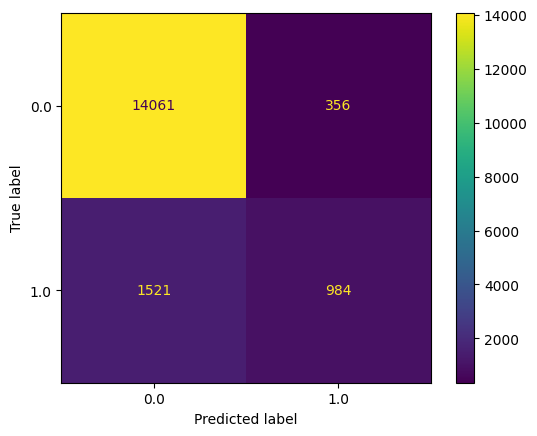

In [ ]:
# week 3 tutorial: part 3, #7

# plot the confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
# Construct the confusion matrix cm
cm = confusion_matrix(y_test, y_pred, labels=logreg.classes_)
# Create a display to plot the confusion matrix
disp = ConfusionMatrixDisplay(cm,display_labels=logreg.classes_)
disp.plot()


              precision    recall  f1-score   support

         0.0       0.90      0.98      0.94     14417
         1.0       0.73      0.39      0.51      2505

    accuracy                           0.89     16922
   macro avg       0.82      0.68      0.72     16922
weighted avg       0.88      0.89      0.87     16922

Accuracy: 0.8890793050466848


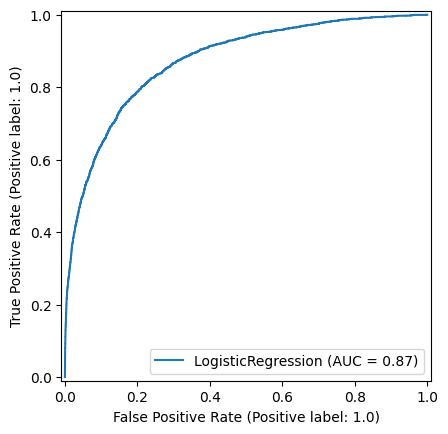

In [ ]:
# get classification report for evaluation (recall, precision, f1-score)
# week 4 notebook - step 8

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

# get accuracy report for evaluation
# code reuse session 2: #12
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


# get AUC-ROC report for evaluation
# code reuse session 3: #15
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(logreg, X_test_scaled, y_test)

In [ ]:
# test loc reg with balanced class weights
# week 3 tutorial: part 3, #5

# import the class
from sklearn.linear_model import LogisticRegression
# instantiate the model (using the default parameters)
logreg2 = LogisticRegression()
# Fit the model using the scaled training data
logreg2.fit(X_train_scaled, y_train)
# Make predictions using the scaled test data
y_pred=logreg2.predict(X_test_scaled)
y_pred

array([0., 0., 0., ..., 0., 0., 0.])

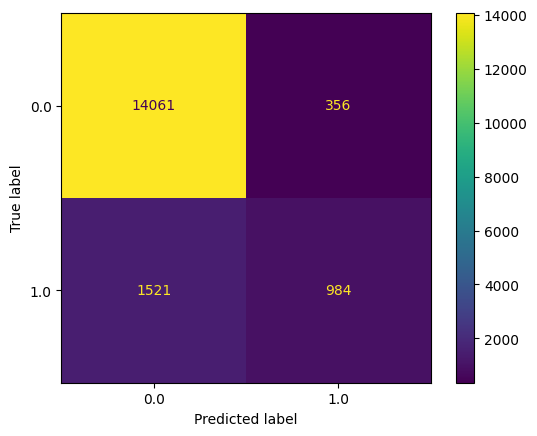

In [ ]:
# build confusion matrix to evaluate new parameter
# week 3 tutorial: part 3, #7

# plot the confusion matrix
# Construct the confusion matrix cm
cm = confusion_matrix(y_test, y_pred, labels=logreg.classes_)
# Create a display to plot the confusion matrix
disp = ConfusionMatrixDisplay(cm,display_labels=logreg.classes_)
disp.plot()


              precision    recall  f1-score   support

         0.0       0.90      0.98      0.94     14417
         1.0       0.73      0.39      0.51      2505

    accuracy                           0.89     16922
   macro avg       0.82      0.68      0.72     16922
weighted avg       0.88      0.89      0.87     16922

Accuracy: 0.8890793050466848


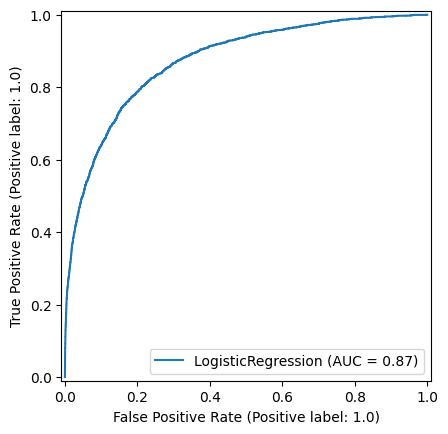

In [ ]:
# get classification report to evaluate new parameter
# week 4 notebook - step 8

print(classification_report(y_test, y_pred))

# get accuracy report for evaluation
# code reuse session 2: #12
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


# get AUC-ROC report for evaluation
# code reuse session 3: #15
RocCurveDisplay.from_estimator(logreg2, X_test_scaled, y_test)


# output is the same

KNN

In [ ]:
# week 4 seminar,  step 9
# Create a KNN classifier

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 9) # hyper paramerter

# Fit the KNN model using the scaled training data
knn.fit(X_train_scaled, y_train)

# Make predictions using the scaled test data
y_pred=knn.predict(X_test_scaled)

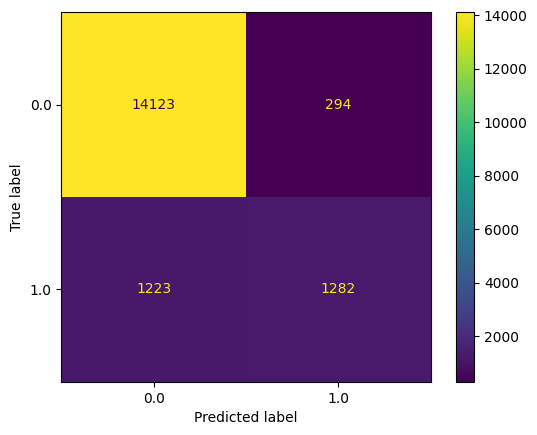

In [ ]:
# week 3 tutorial: part 3, #7



# Costruct the confusion matrix based on…
# comparing actual values (y_test) vs predicted (y_pred) in test data
cm_knn = confusion_matrix(y_test, y_pred, labels = knn.classes_)

#Plot the confusion matrix
disp_knn_cm = ConfusionMatrixDisplay(cm_knn, display_labels=knn.classes_)
disp_knn_cm.plot()



              precision    recall  f1-score   support

         0.0       0.92      0.98      0.95     14417
         1.0       0.81      0.51      0.63      2505

    accuracy                           0.91     16922
   macro avg       0.87      0.75      0.79     16922
weighted avg       0.90      0.91      0.90     16922

Accuracy: 0.9103533861245716


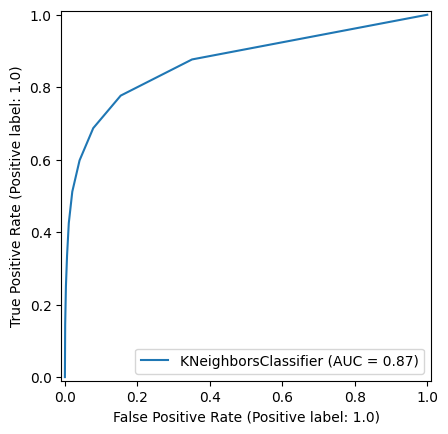

In [ ]:
# get classification report for evaluation (recall, precision, f1-score)
# week 4 notebook - step 8

print(classification_report(y_test, y_pred))

# get accuracy report for evaluation
# code reuse session 2: #12
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


# get AUC-ROC report for evaluation
# code reuse session 3: #15
RocCurveDisplay.from_estimator(knn, X_test_scaled, y_test)

# outcome is very slightly better

Naive Bayes

In [ ]:
# Import Gaussian Naive Bayes
# code resuse session 2 - #27

from sklearn.naive_bayes import GaussianNB

In [ ]:
# tutorial 7 - step 3

# Instantiate the model
nb_model = GaussianNB()

# Fit the model using the scaled training data
nb_model.fit(X_train_scaled, y_train)

GaussianNB()

In [ ]:

# code reuse 2 - 12, 13

# Make predictions using the scaled test data
y_pred_nb = nb_model.predict(X_test_scaled)
y_pred_nb

array([0., 0., 0., ..., 0., 0., 0.])

In [ ]:
# get classification report for evaluation (recall, precision, f1-score)
# week 4 notebook - step 8

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

         0.0       0.90      0.96      0.93     14417
         1.0       0.64      0.40      0.49      2505

    accuracy                           0.88     16922
   macro avg       0.77      0.68      0.71     16922
weighted avg       0.86      0.88      0.87     16922



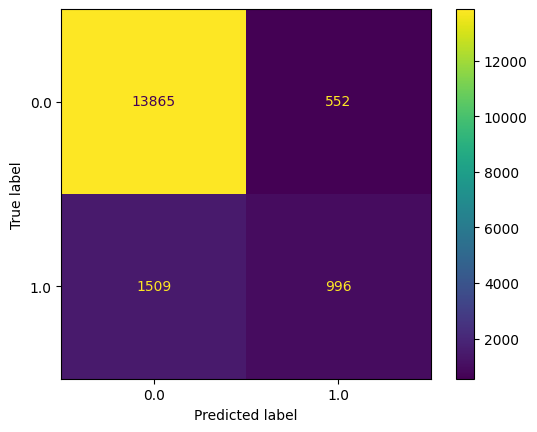

In [ ]:
# week 3 tutorial: part 3, #7

# Construct the confusion matrix based on actual vs predicted results
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=nb_model.classes_)

# Plot the confusion matrix
disp_nb_cm = ConfusionMatrixDisplay(cm_nb, display_labels=nb_model.classes_)
disp_nb_cm.plot()

              precision    recall  f1-score   support

         0.0       0.92      0.98      0.95     14417
         1.0       0.81      0.51      0.63      2505

    accuracy                           0.91     16922
   macro avg       0.87      0.75      0.79     16922
weighted avg       0.90      0.91      0.90     16922

Accuracy: 0.9103533861245716


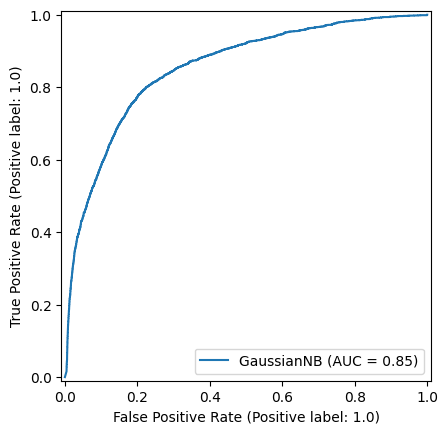

In [ ]:
# get classification report for evaluation (recall, precision, f1-score)
# week 4 notebook - step 8

print(classification_report(y_test, y_pred))

# get accuracy report for evaluation
# code reuse session 2: #12
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


# get AUC-ROC report for evaluation
# code reuse session 3: #15
RocCurveDisplay.from_estimator(nb_model, X_test_scaled, y_test)

optimize KNN - best model

In [ ]:
# find best params using grid search
# Code Reuse Session 2 - # 25, 26
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_neighbors": range(1,15),
    "weights": ["uniform","distance"]
}

grid = GridSearchCV(KNeighborsClassifier(),
                    param_grid,
                    cv=3)

grid.fit(X_train_scaled, y_train)

print("Best parameters:", grid.best_params_)

KeyboardInterrupt: 

In [ ]:
# week 4 seminar,  step 9
# Check KNN outcome with different weights


knn2 = KNeighborsClassifier(n_neighbors = 10, weights='distance') # hyper paramerter

# Fit the KNN model using the scaled training data
knn2.fit(X_train_scaled, y_train)

# Make predictions using the scaled test data
y_pred=knn2.predict(X_test_scaled)

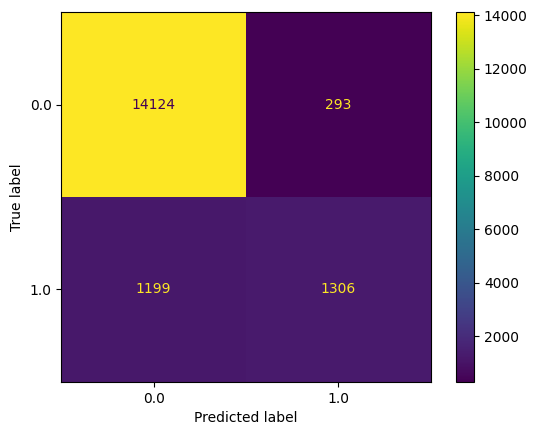

In [ ]:
# week 3 tutorial: part 3, #7



#Costruct the confusion matrix based on…
#comparing actual values (y_test) vs predicted (y_pred) in test data
cm_knn = confusion_matrix(y_test, y_pred, labels = knn2.classes_)

#Plot the confusion matrix
disp_knn_cm = ConfusionMatrixDisplay(cm_knn, display_labels=knn.classes_)
disp_knn_cm.plot()



              precision    recall  f1-score   support

         0.0       0.92      0.98      0.95     14417
         1.0       0.82      0.52      0.64      2505

    accuracy                           0.91     16922
   macro avg       0.87      0.75      0.79     16922
weighted avg       0.91      0.91      0.90     16922

Accuracy: 0.9118307528660915


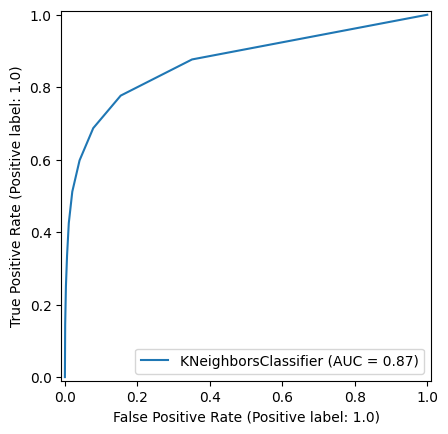

In [ ]:
# get classification report for evaluation (recall, precision, f1-score)
# week 4 notebook - step 8

print(classification_report(y_test, y_pred))

# get accuracy report for evaluation
# code reuse session 2: #12
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


# get AUC-ROC report for evaluation
# code reuse session 3: #15
RocCurveDisplay.from_estimator(knn, X_test_scaled, y_test)